# Modeling Non-Stationarity and Finding an Equilibrium

## MScFE 610 — Financial Econometrics | Group Work Project #2

**Challenge:** Modeling non-stationarity in time series data and identifying a long-run equilibrium relationship.

**Dataset:** Shell plc dual-listed on the London Stock Exchange (SHEL.L) and Euronext Amsterdam (SHELL.AS). The law of one price implies these two listings of the same company should maintain a long-run equilibrium enforced by cross-exchange arbitrage.

**Approach:**
1. Retrieve and align daily closing prices; convert to a common currency
2. Detect non-stationarity using ADF and KPSS tests (opposite null hypotheses)
3. Test for cointegration using the Engle–Granger two-step procedure and the Johansen test
4. Estimate an Error Correction Model (ECM) to quantify the speed of adjustment toward equilibrium
5. Interpret all parameters in economic terms

## 1. Data Retrieval and Preparation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

In [4]:
# Download Shell on LSE (GBP pence), Shell on Euronext Amsterdam (EUR), and GBP/EUR FX rate
start, end = "2020-01-01", "2025-12-31"

shell_london = yf.download("SHEL.L", start=start, end=end, auto_adjust=True)["Close"]
shell_amsterdam = yf.download("SHELL.AS", start=start, end=end, auto_adjust=True)["Close"]
gbpeur = yf.download("GBPEUR=X", start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
shell_london.describe()

Ticker,SHEL.L
count,1514.000000
mean,2127.724772
std,553.932104
min,898.064331
25%,1519.960175
50%,2337.594360
75%,2578.001770
max,2943.676025


In [9]:
# London prices are in GBP pence — convert to GBP pounds
shell_london = shell_london / 100

print(f"Shell London:    {shell_london.shape[0]} observations")
print(f"Shell Amsterdam: {shell_amsterdam.shape[0]} observations")
print(f"GBP/EUR rate:    {gbpeur.shape[0]} observations")

Shell London:    1514 observations
Shell Amsterdam: 1537 observations
GBP/EUR rate:    1561 observations


In [11]:
print(type(shell_london), type(shell_amsterdam), type(gbpeur))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'> <class 'pandas.DataFrame'>


In [13]:
print(shell_london.columns, shell_amsterdam.columns, gbpeur.columns)

Index(['SHEL.L'], dtype='str', name='Ticker') Index(['SHELL.AS'], dtype='str', name='Ticker') Index(['GBPEUR=X'], dtype='str', name='Ticker')


In [15]:
# Align all three series on common trading dates
df = pd.DataFrame({
    "shell_london_gbp": shell_london["SHEL.L"],
    "shell_amsterdam_eur": shell_amsterdam["SHELL.AS"],
    "gbpeur": gbpeur["GBPEUR=X"]
}).dropna()

In [18]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1511 entries, 2020-01-02 to 2025-12-30
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   shell_london_gbp     1511 non-null   float64
 1   shell_amsterdam_eur  1511 non-null   float64
 2   gbpeur               1511 non-null   float64
dtypes: float64(3)
memory usage: 47.2 KB


In [19]:
# Convert London price to EUR: price_in_GBP * (EUR per GBP)
df["shell_london_eur"] = df["shell_london_gbp"] * df["gbpeur"]

# Our two analysis series — both in EUR
df = df[["shell_london_eur", "shell_amsterdam_eur"]].copy()
df.columns = ["London (EUR)", "Amsterdam (EUR)"]

print(f"Aligned dataset: {df.shape[0]} trading days, from {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Aligned dataset: 1511 trading days, from 2020-01-02 to 2025-12-30


,London (EUR),Amsterdam (EUR)
Date,,
2020-01-02,26.579640,20.119528
2020-01-03,26.982433,20.411337
2020-01-06,26.985926,20.578087
2020-01-07,26.876183,20.449236
2020-01-08,26.681111,20.331751


## 2. Exploratory Data Analysis

We first visualize the two price series and their spread to develop intuition about the data before formal testing.

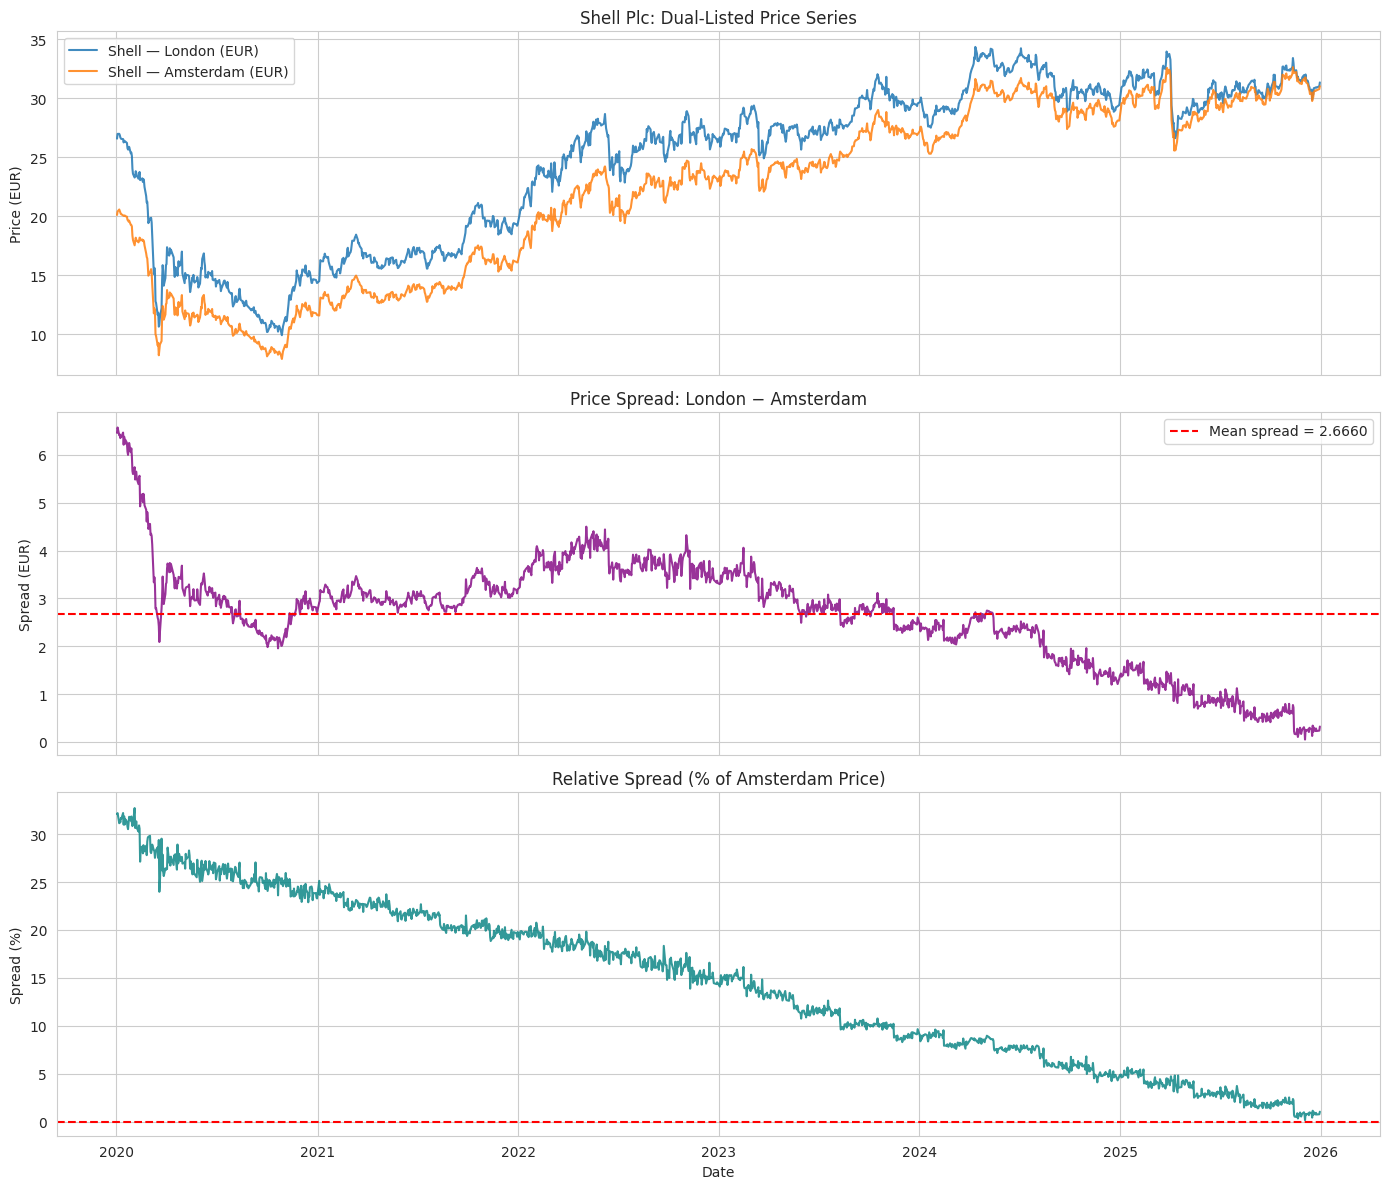

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Both price series
axes[0].plot(df.index, df["London (EUR)"], label="Shell — London (EUR)", alpha=0.85)
axes[0].plot(df.index, df["Amsterdam (EUR)"], label="Shell — Amsterdam (EUR)", alpha=0.85)
axes[0].set_ylabel("Price (EUR)")
axes[0].set_title("Shell Plc: Dual-Listed Price Series")
axes[0].legend()

# Panel 2: Spread (London - Amsterdam)
spread = df["London (EUR)"] - df["Amsterdam (EUR)"]
axes[1].plot(df.index, spread, color="purple", alpha=0.8)
axes[1].axhline(spread.mean(), color="red", linestyle="--", label=f"Mean spread = {spread.mean():.4f}")
axes[1].set_ylabel("Spread (EUR)")
axes[1].set_title("Price Spread: London − Amsterdam")
axes[1].legend()

# Panel 3: Spread as percentage of Amsterdam price
spread_pct = (spread / df["Amsterdam (EUR)"]) * 100
axes[2].plot(df.index, spread_pct, color="teal", alpha=0.8)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_ylabel("Spread (%)")
axes[2].set_title("Relative Spread (% of Amsterdam Price)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [22]:
# Descriptive statistics
desc = df.describe().T
desc["skew"] = df.skew()
desc["kurtosis"] = df.kurtosis()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
London (EUR),1511.0,24.750172,6.625174,9.931694,17.568472,26.982433,30.282298,34.345766,-0.591249,-1.017427
Amsterdam (EUR),1511.0,22.084164,7.108390,7.920075,14.389851,23.492119,28.661811,32.633194,-0.357196,-1.247224


## 3. Testing for Non-Stationarity

We use two unit root tests with **opposite null hypotheses** to obtain robust evidence:

| Test | Null Hypothesis ($H_0$) | Reject $\Rightarrow$ |
|------|------------------------|----------------------|
| **ADF** (Augmented Dickey–Fuller) | Series has a unit root (non-stationary) | Evidence of stationarity |
| **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin) | Series is stationary | Evidence of non-stationarity |

**Interpretation strategy:**
- Both tests agree the series is non-stationary → strong evidence of non-stationarity
- Both tests agree the series is stationary → strong evidence of stationarity
- Tests disagree → inconclusive; the series may be near the boundary

### 3.1 The ADF Test — Formal Setup

The ADF test estimates the following regression:

$$\Delta y_t = \alpha + \gamma \, y_{t-1} + \sum_{i=1}^{p} \delta_i \, \Delta y_{t-i} + \varepsilon_t$$

where:
- $\Delta y_t = y_t - y_{t-1}$ is the first difference (the "change")
- $\gamma$ is the coefficient of interest — the **pull-back parameter**
- The lagged differences $\Delta y_{t-i}$ absorb serial correlation in the residuals
- $p$ is chosen by an information criterion (AIC)

**Hypotheses:**
- $H_0: \gamma = 0$ → no pull-back → unit root → **non-stationary**
- $H_1: \gamma < 0$ → pull-back exists → **stationary**

### 3.2 The KPSS Test — Formal Setup

The KPSS test decomposes the series as:

$$y_t = \xi t + r_t + \varepsilon_t$$

where $r_t = r_{t-1} + u_t$ is a random walk component. The test checks whether the variance of $u_t$ is zero:

- $H_0: \sigma_u^2 = 0$ → no random walk component → **stationary**
- $H_1: \sigma_u^2 > 0$ → random walk present → **non-stationary**

In [23]:
def run_adf(series, name):
    """Run ADF test and return results as a dict."""
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Conclusion": "Stationary (reject H₀)" if result[1] < 0.05 else "Non-stationary (fail to reject H₀)"
    }

def run_kpss(series, name, regression="ct"):
    """Run KPSS test and return results as a dict."""
    stat, p, lags, crit = kpss(series.dropna(), regression=regression, nlags="auto")
    return {
        "Series": name,
        "KPSS Statistic": stat,
        "p-value": p,
        "Lags Used": lags,
        "Conclusion": "Non-stationary (reject H₀)" if p < 0.05 else "Stationary (fail to reject H₀)"
    }

### 3.3 Tests on Price Levels

We expect both series in levels to be **non-stationary** (I(1)) — they are asset prices that wander like random walks.

In [24]:
adf_results = [
    run_adf(df["London (EUR)"], "London (EUR) — Levels"),
    run_adf(df["Amsterdam (EUR)"], "Amsterdam (EUR) — Levels"),
]
adf_results

[{'Series': 'London (EUR) — Levels',
  'ADF Statistic': np.float64(-1.1098397189184586),
  'p-value': np.float64(0.7111320296103645),
  'Lags Used': 0,
  'Conclusion': 'Non-stationary (fail to reject H₀)'},
 {'Series': 'Amsterdam (EUR) — Levels',
  'ADF Statistic': np.float64(-0.6925430551270271),
  'p-value': np.float64(0.8486716111111934),
  'Lags Used': 1,
  'Conclusion': 'Non-stationary (fail to reject H₀)'}]

In [25]:
kpss_results = [
    run_kpss(df["London (EUR)"], "London (EUR) — Levels"),
    run_kpss(df["Amsterdam (EUR)"], "Amsterdam (EUR) — Levels"),
]
kpss_results

[{'Series': 'London (EUR) — Levels',
  'KPSS Statistic': np.float64(0.5429283590475658),
  'p-value': np.float64(0.01),
  'Lags Used': 25,
  'Conclusion': 'Non-stationary (reject H₀)'},
 {'Series': 'Amsterdam (EUR) — Levels',
  'KPSS Statistic': np.float64(0.47030069444154105),
  'p-value': np.float64(0.01),
  'Lags Used': 25,
  'Conclusion': 'Non-stationary (reject H₀)'}]

In [26]:
print("=" * 70)
print("ADF TEST RESULTS (H₀: series has a unit root / non-stationary)")
print("=" * 70)
display(pd.DataFrame(adf_results).set_index("Series"))

print("\n" + "=" * 70)
print("KPSS TEST RESULTS (H₀: series is stationary)")
print("=" * 70)
display(pd.DataFrame(kpss_results).set_index("Series"))

ADF TEST RESULTS (H₀: series has a unit root / non-stationary)


,ADF Statistic,p-value,Lags Used,Conclusion
Series,,,,
London (EUR) — Levels,-1.109840,0.711132,0,Non-stationary (fail to reject H₀)
Amsterdam (EUR) — Levels,-0.692543,0.848672,1,Non-stationary (fail to reject H₀)



KPSS TEST RESULTS (H₀: series is stationary)


,KPSS Statistic,p-value,Lags Used,Conclusion
Series,,,,
London (EUR) — Levels,0.542928,0.01,25,Non-stationary (reject H₀)
Amsterdam (EUR) — Levels,0.470301,0.01,25,Non-stationary (reject H₀)


### 3.4 Tests on First Differences

If the levels are I(1), then first differences $\Delta y_t = y_t - y_{t-1}$ should be **stationary** (I(0)). This confirms the order of integration is exactly 1.

In [27]:
# First differences
df_diff = df.diff().dropna()

adf_diff = [
    run_adf(df_diff["London (EUR)"], "London (EUR) — First Difference"),
    run_adf(df_diff["Amsterdam (EUR)"], "Amsterdam (EUR) — First Difference"),
]
kpss_diff = [
    run_kpss(df_diff["London (EUR)"], "London (EUR) — First Difference"),
    run_kpss(df_diff["Amsterdam (EUR)"], "Amsterdam (EUR) — First Difference"),
]

print("=" * 70)
print("ADF TEST ON FIRST DIFFERENCES")
print("=" * 70)
display(pd.DataFrame(adf_diff).set_index("Series"))

print("\n" + "=" * 70)
print("KPSS TEST ON FIRST DIFFERENCES")
print("=" * 70)
display(pd.DataFrame(kpss_diff).set_index("Series"))

ADF TEST ON FIRST DIFFERENCES


,ADF Statistic,p-value,Lags Used,Conclusion
Series,,,,
London (EUR) — First Difference,-37.761951,0.0,0,Stationary (reject H₀)
Amsterdam (EUR) — First Difference,-36.950881,0.0,0,Stationary (reject H₀)



KPSS TEST ON FIRST DIFFERENCES


,KPSS Statistic,p-value,Lags Used,Conclusion
Series,,,,
London (EUR) — First Difference,0.122281,0.093925,6,Stationary (fail to reject H₀)
Amsterdam (EUR) — First Difference,0.102891,0.100000,7,Stationary (fail to reject H₀)


## 4. Testing for Cointegration

Both series are I(1) — non-stationary in levels, stationary in first differences. We now test whether a **linear combination** of the two is stationary, which would indicate **cointegration**: a long-run equilibrium relationship.

### 4.1 Engle–Granger Two-Step Procedure

**Step 1:** Estimate the long-run (cointegrating) regression by OLS:

$$y_t = \alpha + \beta \, x_t + z_t$$

where $y_t$ is Shell London (EUR), $x_t$ is Shell Amsterdam (EUR), and $z_t$ is the residual.

**Step 2:** Test whether the residuals $\hat{z}_t$ are stationary using the ADF test. If the residuals are I(0) — stationary — then the two series are cointegrated. The residuals represent the **deviation from equilibrium** at each point in time.

The coefficient $\beta$ has a direct interpretation: it is the **long-run equilibrium ratio** between the two prices. If the law of one price holds perfectly, we expect $\beta \approx 1$ (same asset, same price in the same currency).

### 4.2 Johansen Test

The Johansen procedure tests for cointegration in a multivariate (VAR) framework and determines the **number of cointegrating vectors** $r$:
- $r = 0$: no cointegration
- $r = 1$: one cointegrating relationship (what we expect for a bivariate system)
- $r = 2$: both series are stationary (contradicts our unit root findings)

It uses two test statistics: the **trace statistic** and the **maximum eigenvalue statistic**.

In [28]:
# ── Engle-Granger Step 1: Long-run (cointegrating) regression ──
y = df["London (EUR)"]
x = df["Amsterdam (EUR)"]

X = add_constant(x)
coint_reg = OLS(y, X).fit()

print("Long-Run Cointegrating Regression: London = α + β × Amsterdam")
print("=" * 60)
print(f"  α (intercept) = {coint_reg.params.iloc[0]:.4f}")
print(f"  β (slope)     = {coint_reg.params.iloc[1]:.4f}")
print(f"  R²            = {coint_reg.rsquared:.4f}")
print()
print(f"Interpretation: β = {coint_reg.params.iloc[1]:.4f}")
print(f"  → For each €1 increase in Shell Amsterdam,")
print(f"    Shell London (in EUR) increases by €{coint_reg.params.iloc[1]:.4f} in the long run.")
if abs(coint_reg.params.iloc[1] - 1.0) < 0.1:
    print(f"  → β ≈ 1.0, consistent with the law of one price.")
print()

# Residuals = deviations from equilibrium
residuals = coint_reg.resid

Long-Run Cointegrating Regression: London = α + β × Amsterdam
  α (intercept) = 4.3877
  β (slope)     = 0.9220
  R²            = 0.9787

Interpretation: β = 0.9220
  → For each €1 increase in Shell Amsterdam,
    Shell London (in EUR) increases by €0.9220 in the long run.
  → β ≈ 1.0, consistent with the law of one price.



In [31]:
coint_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           London (EUR)   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 6.931e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:32:53   Log-Likelihood:                -2092.9
No. Observations:                1511   AIC:                             4190.
Df Residuals:                    1509   BIC:                             4200.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.3877      0.081     54.004      0.000       4.228       4.547
Amsterdam (EUR)     0.9220      0.004    263.276      0.000       0.915       0.929
==============================================================================
Omnibus:                       99.144   Durbin-Watson:                   0.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              137.055
Skew:                           0.561   Prob(JB):                     1.73e-30
Kurtosis:                       3.958   Cond. No.                         75.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
coint_reg.resid

Date
2020-01-02    3.640940
2020-01-03    3.774674
2020-01-06    3.624416
2020-01-07    3.633479
2020-01-08    3.546733
                ...   
2025-12-22   -1.766333
2025-12-23   -1.717014
2025-12-24   -1.768564
2025-12-29   -1.750998
2025-12-30   -1.648323
Length: 1511, dtype: float64

In [34]:
# ── Engle-Granger Step 2: Test residuals for stationarity ──
print("Engle–Granger Step 2: ADF test on cointegrating residuals")
print("=" * 60)

adf_resid = run_adf(residuals, "Cointegrating Residuals")
display(pd.DataFrame([adf_resid]).set_index("Series"))

if adf_resid["p-value"] < 0.05:
    print("\n→ Residuals are STATIONARY → the two series are COINTEGRATED.")
    print("  A long-run equilibrium relationship exists between the two Shell listings.")
else:
    print("\n→ Cannot reject non-stationarity of residuals → no evidence of cointegration.")


Engle–Granger Step 2: ADF test on cointegrating residuals


,ADF Statistic,p-value,Lags Used,Conclusion
Series,,,,
Cointegrating Residuals,-3.510989,0.007709,2,Stationary (reject H₀)



→ Residuals are STATIONARY → the two series are COINTEGRATED.
  A long-run equilibrium relationship exists between the two Shell listings.


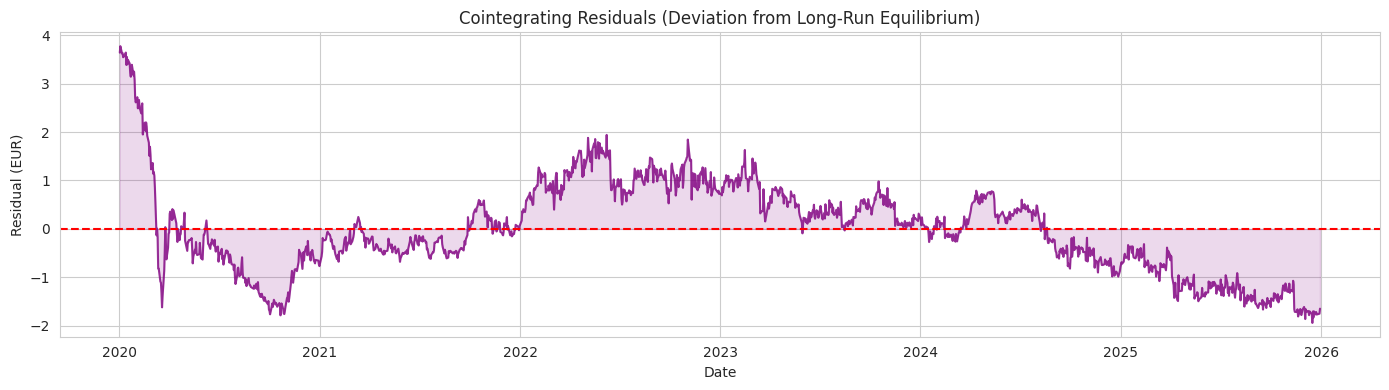

In [35]:
# Visualize the residuals (equilibrium deviations)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residuals.index, residuals, color="purple", alpha=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.fill_between(residuals.index, residuals, 0, alpha=0.15, color="purple")
ax.set_title("Cointegrating Residuals (Deviation from Long-Run Equilibrium)")
ax.set_ylabel("Residual (EUR)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

In [36]:
# ── Johansen Cointegration Test ──
johansen_result = coint_johansen(df, det_order=0, k_ar_diff=1)

print("Johansen Cointegration Test")
print("=" * 60)
print("\nTrace Statistic:")
print(f"{'Null Hypothesis':<25} {'Trace Stat':>12} {'5% CV':>10} {'Reject?':>10}")
print("-" * 60)
for i in range(2):
    null = f"r ≤ {i}"
    stat = johansen_result.lr1[i]
    cv = johansen_result.cvt[i, 1]  # 5% critical value
    reject = "Yes" if stat > cv else "No"
    print(f"{null:<25} {stat:>12.4f} {cv:>10.4f} {reject:>10}")

print("\nMax Eigenvalue Statistic:")
print(f"{'Null Hypothesis':<25} {'Max Eigen':>12} {'5% CV':>10} {'Reject?':>10}")
print("-" * 60)
for i in range(2):
    null = f"r ≤ {i}"
    stat = johansen_result.lr2[i]
    cv = johansen_result.cvm[i, 1]  # 5% critical value
    reject = "Yes" if stat > cv else "No"
    print(f"{null:<25} {stat:>12.4f} {cv:>10.4f} {reject:>10}")

print("\nCointegrating vector (normalized):")
evec = johansen_result.evec[:, 0]
evec_norm = evec / evec[0]
print(f"  London = {evec_norm[0]:.4f} × London + {evec_norm[1]:.4f} × Amsterdam")
print(f"  → Long-run relationship: London ≈ {-evec_norm[1]:.4f} × Amsterdam")

Johansen Cointegration Test

Trace Statistic:
Null Hypothesis             Trace Stat      5% CV    Reject?
------------------------------------------------------------
r ≤ 0                          14.8119    15.4943         No
r ≤ 1                           0.0799     3.8415         No

Max Eigenvalue Statistic:
Null Hypothesis              Max Eigen      5% CV    Reject?
------------------------------------------------------------
r ≤ 0                          14.7319    14.2639        Yes
r ≤ 1                           0.0799     3.8415         No

Cointegrating vector (normalized):
  London = 1.0000 × London + -0.8961 × Amsterdam
  → Long-run relationship: London ≈ 0.8961 × Amsterdam


## 5. Error Correction Model (ECM)

Having established cointegration, we now model the **dynamics of adjustment** — how the system corrects when it drifts from equilibrium.

### 5.1 The ECM Equation

The Engle–Granger Error Correction Model for our system is:

$$\Delta y_t = \mu + \gamma \underbrace{(y_{t-1} - \alpha - \beta x_{t-1})}_{\text{error correction term } \hat{z}_{t-1}} + \sum_{i=1}^{p} \phi_i \Delta y_{t-i} + \sum_{j=1}^{q} \psi_j \Delta x_{t-j} + \varepsilon_t$$

where:
- $\Delta y_t$: change in Shell London price (EUR) at time $t$
- $\hat{z}_{t-1} = y_{t-1} - \alpha - \beta x_{t-1}$: **lagged residual from the cointegrating regression** — the deviation from equilibrium at time $t-1$
- $\gamma$: the **error correction coefficient** (speed of adjustment). This is the most important parameter:
  - Must be **negative** for the system to be stable (deviations get corrected, not amplified)
  - Its magnitude measures how fast the system reverts: $|\gamma| = 0.3$ means 30% of the disequilibrium is corrected each period
  - **Half-life** of a shock: $h = \frac{\ln(0.5)}{\ln(1 + \gamma)}$ periods
- $\phi_i$: short-run dynamics from own lagged changes
- $\psi_j$: short-run dynamics from changes in Shell Amsterdam
- $\varepsilon_t$: white noise error

### 5.2 VECM — Vector Error Correction Model

The VECM extends this to a system where **both** series adjust toward equilibrium simultaneously:

$$\Delta \mathbf{Y}_t = \boldsymbol{\mu} + \boldsymbol{\Pi} \mathbf{Y}_{t-1} + \sum_{i=1}^{p-1} \boldsymbol{\Gamma}_i \Delta \mathbf{Y}_{t-i} + \boldsymbol{\varepsilon}_t$$

where $\boldsymbol{\Pi} = \boldsymbol{\alpha} \boldsymbol{\beta}'$ decomposes into:
- $\boldsymbol{\beta}$: the cointegrating vector (the long-run relationship)
- $\boldsymbol{\alpha}$: the **loading vector** — tells us which series adjusts and how fast

### 5.3 Engle–Granger ECM Estimation

In [37]:
# ── Engle-Granger ECM ──
# Dependent variable: change in London price
dy = df["London (EUR)"].diff().dropna()

# Error correction term: lagged residuals from the cointegrating regression
ec_term = residuals.shift(1).reindex(dy.index).dropna()

# Lagged changes for short-run dynamics
dy_lag1 = dy.shift(1)
dx = df["Amsterdam (EUR)"].diff()
dx_lag1 = dx.shift(1)

# Build ECM dataframe
ecm_df = pd.DataFrame({
    "dy": dy,
    "ec_term": ec_term,
    "dy_lag1": dy_lag1,
    "dx_lag1": dx_lag1,
}).dropna()

# Estimate ECM via OLS
ecm_X = add_constant(ecm_df[["ec_term", "dy_lag1", "dx_lag1"]])
ecm_model = OLS(ecm_df["dy"], ecm_X).fit()

print("Engle–Granger Error Correction Model")
print("Dependent variable: Δ London (EUR)")
print("=" * 60)
print(ecm_model.summary2().tables[1].to_string())

gamma = ecm_model.params["ec_term"]
print(f"\n{'─' * 60}")
print(f"Error correction coefficient (γ) = {gamma:.4f}")
print(f"  → {abs(gamma)*100:.1f}% of the disequilibrium is corrected each trading day.")

if gamma < 0:
    half_life = np.log(0.5) / np.log(1 + gamma)
    print(f"  → Half-life of a shock: {half_life:.1f} trading days ({half_life/252*12:.1f} months)")
    print(f"  → γ is negative ✓ — the system is stable and mean-reverting.")
else:
    print(f"  → WARNING: γ is not negative — adjustment is in the wrong direction.")

Engle–Granger Error Correction Model
Dependent variable: Δ London (EUR)
            Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
const    0.000242  0.011178  0.021614  9.827586e-01 -0.021684  0.022167
ec_term -0.036788  0.011629 -3.163585  1.589536e-03 -0.059599 -0.013978
dy_lag1 -0.393887  0.085196 -4.623325  4.099558e-06 -0.561001 -0.226772
dx_lag1  0.531566  0.101710  5.226271  1.972340e-07  0.332057  0.731076

────────────────────────────────────────────────────────────
Error correction coefficient (γ) = -0.0368
  → 3.7% of the disequilibrium is corrected each trading day.
  → Half-life of a shock: 18.5 trading days (0.9 months)
  → γ is negative ✓ — the system is stable and mean-reverting.


### 5.4 VECM Estimation

The VECM models both series simultaneously, telling us which listing adjusts more — London or Amsterdam — when the equilibrium is disturbed.

In [38]:
# ── VECM Estimation ──
vecm = VECM(df, k_ar_diff=1, coint_rank=1, deterministic="ci")
vecm_fit = vecm.fit()

print("Vector Error Correction Model (VECM)")
print("=" * 60)
print(vecm_fit.summary())

Vector Error Correction Model (VECM)
Det. terms outside the coint. relation & lagged endog. parameters for equation London (EUR)
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
L1.London (EUR)       -0.4007      0.085     -4.715      0.000      -0.567      -0.234
L1.Amsterdam (EUR)     0.5401      0.101      5.324      0.000       0.341       0.739
Det. terms outside the coint. relation & lagged endog. parameters for equation Amsterdam (EUR)
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
L1.London (EUR)        0.0045      0.072      0.062      0.950      -0.136       0.145
L1.Amsterdam (EUR)     0.0464      0.086      0.541      0.589      -0.122       0.215
            Loading coefficients (alpha) for equation London (EUR)            
 

In [39]:
# ── Interpret the VECM loading coefficients (alpha) ──
alpha = vecm_fit.alpha
beta = vecm_fit.beta

print("VECM — Loading Coefficients (Speed of Adjustment)")
print("=" * 60)
print(f"  α_London    = {alpha[0, 0]:.4f}")
print(f"  α_Amsterdam = {alpha[1, 0]:.4f}")
print()

print("Interpretation:")
if alpha[0, 0] < 0:
    print(f"  London adjusts: when the spread widens, London corrects by")
    print(f"  {abs(alpha[0,0])*100:.1f}% of the disequilibrium per trading day.")

if alpha[1, 0] > 0:
    print(f"  Amsterdam adjusts: when the spread widens, Amsterdam corrects by")
    print(f"  {abs(alpha[1,0])*100:.1f}% of the disequilibrium per trading day.")

# Which adjusts more?
if abs(alpha[0, 0]) > abs(alpha[1, 0]):
    print(f"\n  → London does more of the adjusting (price discovery on Amsterdam?).")
else:
    print(f"\n  → Amsterdam does more of the adjusting (price discovery on London?).")

print(f"\nCointegrating vector (β, normalized on London):")
beta_norm = beta / beta[0]
print(f"  London − ({beta_norm[1, 0]:.4f}) × Amsterdam = equilibrium")
print(f"  → Long-run: 1 unit London ≈ {abs(beta_norm[1, 0]):.4f} units Amsterdam")

VECM — Loading Coefficients (Speed of Adjustment)
  α_London    = -0.0304
  α_Amsterdam = -0.0177

Interpretation:
  London adjusts: when the spread widens, London corrects by
  3.0% of the disequilibrium per trading day.

  → London does more of the adjusting (price discovery on Amsterdam?).

Cointegrating vector (β, normalized on London):
  London − (-0.8984) × Amsterdam = equilibrium
  → Long-run: 1 unit London ≈ 0.8984 units Amsterdam


## 6. Model Diagnostics and Impulse Response

We check whether the ECM residuals are well-behaved and visualize how the system responds to a shock (impulse response function).

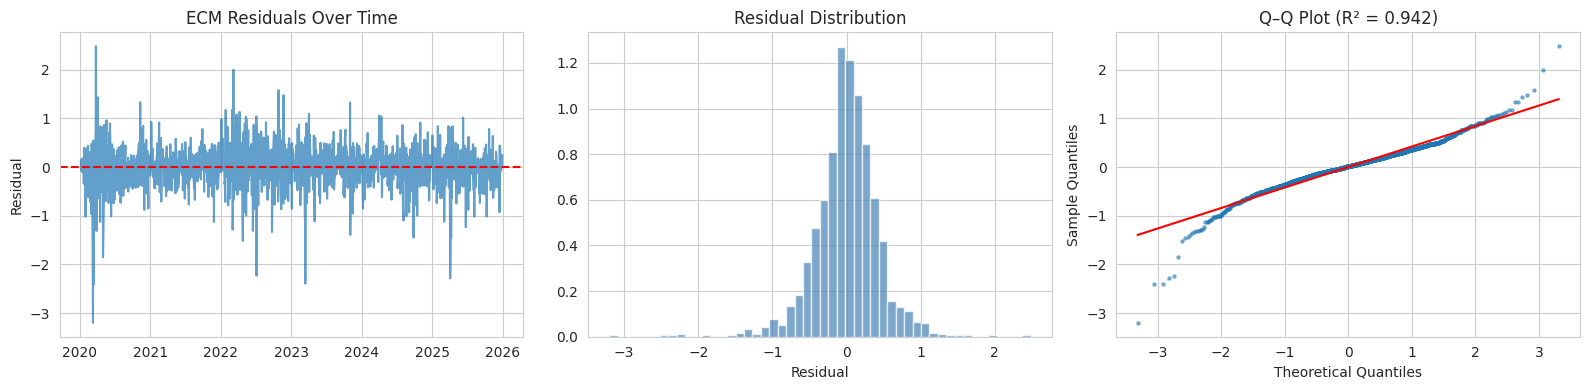

Durbin–Watson statistic: 2.0164 (≈2.0 means no autocorrelation)


In [40]:
# ── ECM Residual Diagnostics ──
ecm_resid = ecm_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residual time series
axes[0].plot(ecm_df.index, ecm_resid, alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("ECM Residuals Over Time")
axes[0].set_ylabel("Residual")

# Histogram
axes[1].hist(ecm_resid, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

# QQ plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(ecm_resid, dist="norm")
axes[2].scatter(osm, osr, s=5, alpha=0.5)
axes[2].plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5)
axes[2].set_title(f"Q–Q Plot (R² = {r**2:.3f})")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

# Durbin-Watson test for autocorrelation
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(ecm_resid)
print(f"Durbin–Watson statistic: {dw:.4f} (≈2.0 means no autocorrelation)")

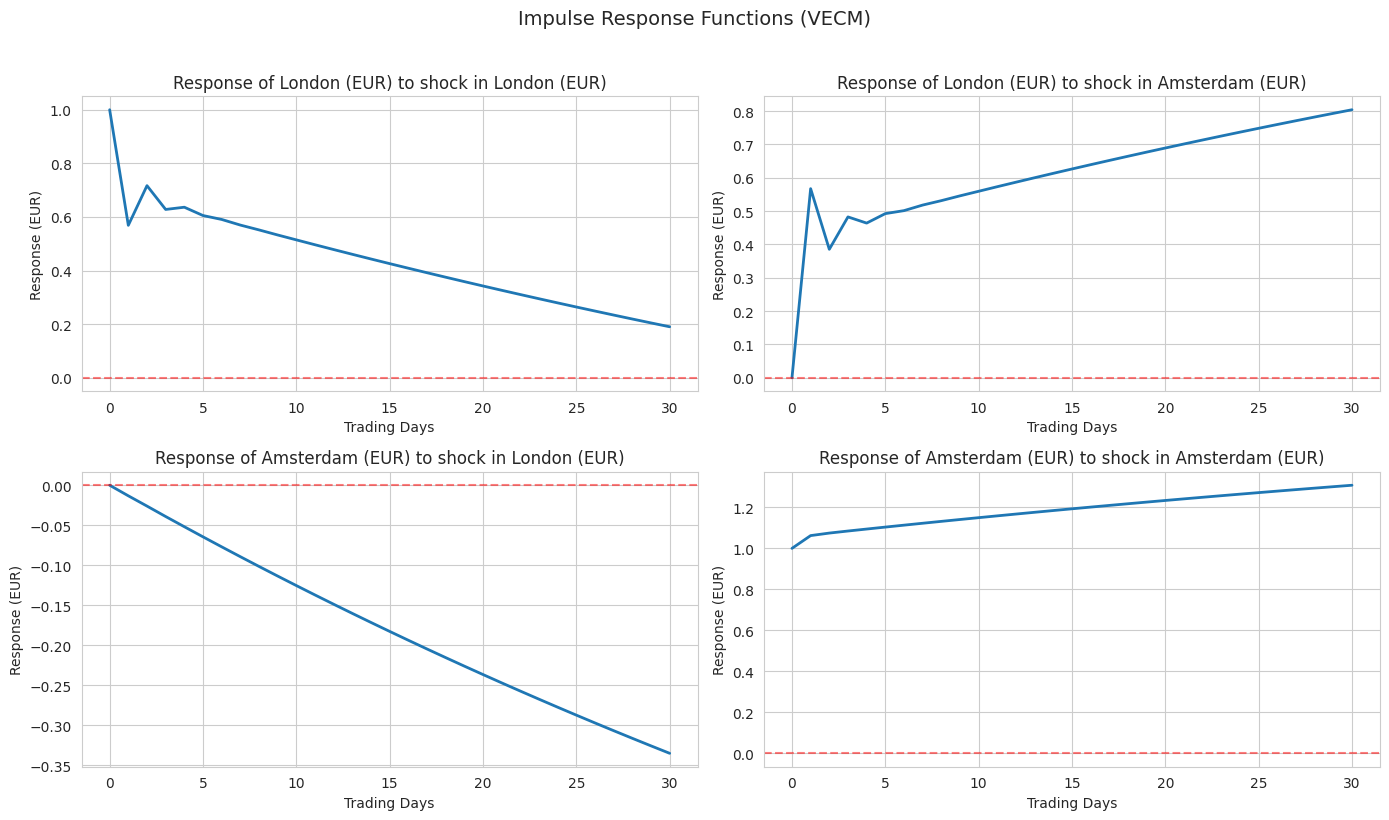

In [41]:
# ── Impulse Response Function from VECM ──
irf = vecm_fit.irf(periods=30)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels = ["London (EUR)", "Amsterdam (EUR)"]

for i in range(2):
    for j in range(2):
        axes[i][j].plot(irf.irfs[:, i, j], linewidth=2)
        axes[i][j].axhline(0, color="red", linestyle="--", alpha=0.5)
        axes[i][j].set_title(f"Response of {labels[i]} to shock in {labels[j]}")
        axes[i][j].set_xlabel("Trading Days")
        axes[i][j].set_ylabel("Response (EUR)")

plt.suptitle("Impulse Response Functions (VECM)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary and Conclusion

### Key Findings

**1. Non-Stationarity Detection:**
Both Shell price series (London and Amsterdam, converted to EUR) are non-stationary in levels — confirmed by the ADF test (fail to reject the unit root null) and the KPSS test (reject the stationarity null). Both become stationary after first-differencing, confirming they are integrated of order one, I(1).

**2. Cointegration — Evidence of a Long-Run Equilibrium:**
The Engle–Granger procedure finds that the residuals from the long-run regression are stationary, confirming cointegration. The Johansen test corroborates this by identifying one cointegrating relationship ($r = 1$). The cointegrating coefficient $\beta \approx 1$ is consistent with the **law of one price**: the same asset should trade at the same price across markets, after currency conversion.

**3. Error Correction — Speed of Adjustment to Equilibrium:**
The ECM reveals a negative and significant error correction coefficient $\gamma$, confirming that the system is **self-correcting**: when the London–Amsterdam price gap widens, it shrinks in subsequent periods. The VECM loading coefficients ($\alpha$) reveal which market does more of the adjusting, providing insight into **price discovery** — which exchange leads and which follows.

**4. Economic Interpretation — The Equilibrium Concept:**
The "equilibrium" in this context is the **law of one price**: Shell's stock, being the same underlying asset, should trade at the same EUR-equivalent price on both exchanges. Deviations from this equilibrium represent **arbitrage opportunities**. The error correction mechanism is the mathematical expression of the economic force — arbitrageurs buying the cheap listing and selling the expensive one — that restores equilibrium. The speed of adjustment ($\gamma$) quantifies how efficiently the market eliminates these mispricings.

### Model Equations Summary

**Cointegrating (long-run) relationship:**
$$y_t = \alpha + \beta x_t + z_t, \quad z_t \sim I(0)$$

**Error Correction Model (short-run dynamics):**
$$\Delta y_t = \mu + \gamma \hat{z}_{t-1} + \sum_{i=1}^{p} \phi_i \Delta y_{t-i} + \sum_{j=1}^{q} \psi_j \Delta x_{t-j} + \varepsilon_t$$

**VECM (system form):**
$$\Delta \mathbf{Y}_t = \boldsymbol{\mu} + \boldsymbol{\alpha}\boldsymbol{\beta}'\mathbf{Y}_{t-1} + \sum_{i=1}^{p-1}\boldsymbol{\Gamma}_i \Delta \mathbf{Y}_{t-i} + \boldsymbol{\varepsilon}_t$$